![alt text](../img/general/header.png)

## High-Level Synthesis for Machine Learning (hls4ml)


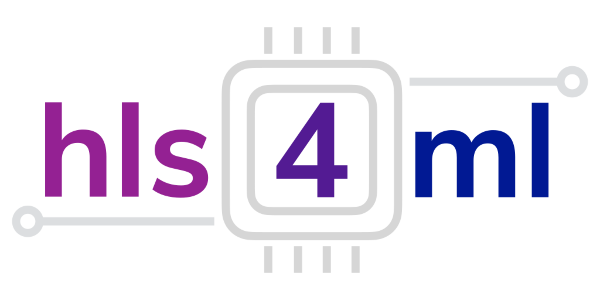

💡 **High-Level Synthesis for Machine Learning (hls4ml)** es una biblioteca de código abierto diseñada para convertir modelos de aprendizaje automático en descripciones de hardware optimizadas para su implementación en FPGAs 

**Características de hls4ml:** 

- Convierte modelos de Keras, TensorFlow, PyTorch, y ONNX en proyectos HLS (High-Level Synthesis).

- Usa herramientas como Xilinx Vitis HLS y Intel HLS Compiler para generar código en C++ optimizado para hardware.

- Permite reducir la latencia y el consumo de energía, mejorando la eficiencia en implementaciones de IA en edge computing.

- Soporta técnicas de cuantización y pruning para reducir el tamaño del modelo sin afectar significativamente su precisión.

**Aplicaciones de hls4ml:**

- Procesamiento en tiempo real en sistemas embebidos.

- Implementación de redes neuronales en hardware de baja potencia.

- Aceleración de modelos de IA en aplicaciones como física de partículas, visión artificial y robótica.


Para más información:

- GitHub: https://github.com/fastmachinelearning/hls4ml

- Web site: https://fastmachinelearning.org/hls4ml/

---

### Librerías

In [2]:
import os
import numpy as np
import tensorflow as tf 
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from qkeras import *
from qkeras import QActivation
from qkeras import QDense, QConv2DBatchnorm
import hls4ml
import matplotlib.pyplot as plt


2025-04-08 22:33:34.160727: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-08 22:33:35.283397: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-08 22:33:35.290836: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-08 22:33:39.850954: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### Path a Vitis HLS


Como paso inicial se debe especificar el directorio de instalación de Vivado HLS o Vitis HLS. 

In [3]:
# Path donde se encuentra instalado Vitis HLS!! 

os.environ['PATH'] = '/home/user/Xilinx/Vitis_HLS/2024.2/bin:' + os.environ['PATH']

# # Para MÁQUINA VIRTUAL!
# os.environ['PATH'] = '/tools/Xilinx/Vitis_HLS/2022.2/bin/vitis_hls:' + os.environ['PATH']

# os.environ['PATH']


### Carga del modelo (.h5)

Carga del modelo pre-entrenado y guardado en formato **.h5**. 

Para este laboratorio, el modelo fue generado en el **lab03**.

In [6]:

from qkeras.utils import _add_supported_quantized_objects
co = {}
_add_supported_quantized_objects(co)

os.getcwd()

model = load_model('mnistPQKD.h5', custom_objects=co)
    
# Resumen del modelo
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1_input (QDense)          (None, 5)                 3925      
                                                                 
 relu_input (QActivation)    (None, 5)                 0         
                                                                 
 fc1 (QDense)                (None, 7)                 42        
                                                                 
 relu1 (QActivation)         (None, 7)                 0         
                                                                 
 fc2 (QDense)                (None, 10)                80        
                                                                 
 relu2 (QActivation)         (None, 10)                0         
                                                                 
 output (QDense)             (None, 2)                 2

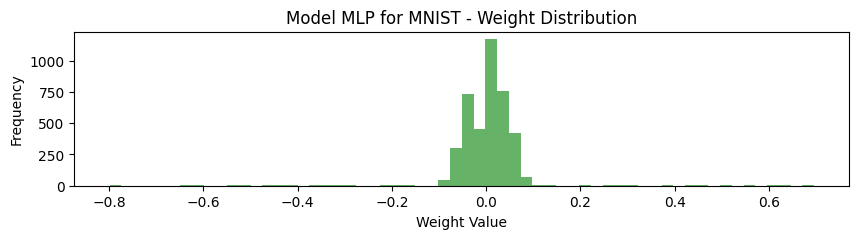

In [7]:
# Weight distribution

weights = np.concatenate([w.flatten() for w in model.get_weights()])

plt.figure(figsize=(10,2))
plt.hist(weights, bins=60, color='green', alpha=0.6)
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.title("Model MLP for MNIST - Weight Distribution")
plt.show()


### hls4ml 

💡 Arbitrary precision reference: https://docs.amd.com/r/2022.2-English/ug1399-vitis-hls/Fixed-Point-Identifier-Summary?tocId=jgeN4rPFF_M6nxbDn1H5HA

In [8]:

hls_config = hls4ml.utils.config_from_keras_model(model, granularity='name')

import plotting

print("-----------------------------------")
plotting.print_dict(hls_config)
print("-----------------------------------")




Interpreting Sequential
Topology:
Layer name: fc1_input_input, layer type: InputLayer, input shapes: [[None, 784]], output shape: [None, 784]
Layer name: fc1_input, layer type: QDense, input shapes: [[None, 784]], output shape: [None, 5]
Layer name: relu_input, layer type: Activation, input shapes: [[None, 5]], output shape: [None, 5]
Layer name: fc1, layer type: QDense, input shapes: [[None, 5]], output shape: [None, 7]
Layer name: relu1, layer type: Activation, input shapes: [[None, 7]], output shape: [None, 7]
Layer name: fc2, layer type: QDense, input shapes: [[None, 7]], output shape: [None, 10]
Layer name: relu2, layer type: Activation, input shapes: [[None, 10]], output shape: [None, 10]
Layer name: output, layer type: QDense, input shapes: [[None, 10]], output shape: [None, 2]
Layer name: sigmoid, layer type: Activation, input shapes: [[None, 2]], output shape: [None, 2]
-----------------------------------
Model
  Precision:         fixed<16,6>
  ReuseFactor:       1
  Strategy

In [10]:
from hls4ml.model.profiling import numerical, get_ymodel_keras

# the name of the different layers could be different!! 

# hls_config['LayerName']['flatten_22_input']['Precision'] = 'ap_fixed<16, 6>'  
# hls_config['LayerName']['flatten_22']['Precision'] = 'ap_fixed<8, 2>'  

# hls_config['LayerName']['fc3']['Precision'] = 'ap_fixed<8, 2>'  

# hls_config['LayerName']['relu_input']['Precision'] = 'ap_fixed<8, 3>'
hls_config['LayerName']['sigmoid']['Strategy'] = 'Stable'

hls_config['Model']['Precision'] = 'ap_fixed<8,4>'



### hls4ml con Vitis HLS como backend

In [11]:
cfg = hls4ml.converters.create_config(backend='Vitis')

cfg['IOType']     = 'io_stream'   # Must set this if using CNNs!
cfg['HLSConfig']  = hls_config      # HLS configuraiton
cfg['KerasModel'] = model           # Keras model to be converted
cfg['OutputDir']  = 'hlsPrj/'       # Project name
cfg['Part'] = 'xc7z020clg484-1'     # PYNQ-Z1 or Zedboard: xc7z020clg484-1  ARTIX-7 xc7a35tcsg325-1  # MPSoC xczu4eg-sfvc784-2-e  xczu3eg-sfvc784-1-e


hls_model = hls4ml.converters.keras_to_hls(cfg)

hls_model.compile()

Interpreting Sequential
Topology:
Layer name: fc1_input_input, layer type: InputLayer, input shapes: [[None, 784]], output shape: [None, 784]
Layer name: fc1_input, layer type: QDense, input shapes: [[None, 784]], output shape: [None, 5]
Layer name: relu_input, layer type: Activation, input shapes: [[None, 5]], output shape: [None, 5]
Layer name: fc1, layer type: QDense, input shapes: [[None, 5]], output shape: [None, 7]
Layer name: relu1, layer type: Activation, input shapes: [[None, 7]], output shape: [None, 7]
Layer name: fc2, layer type: QDense, input shapes: [[None, 7]], output shape: [None, 10]
Layer name: relu2, layer type: Activation, input shapes: [[None, 10]], output shape: [None, 10]
Layer name: output, layer type: QDense, input shapes: [[None, 10]], output shape: [None, 2]
Layer name: sigmoid, layer type: Activation, input shapes: [[None, 2]], output shape: [None, 2]
Creating HLS model
Writing HLS project


Done


In [12]:
hls_model.build(csim=False, export=False)


****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.2 (64-bit)
  **** SW Build 5238294 on Nov  8 2024
  **** IP Build 5239520 on Sun Nov 10 16:12:51 MST 2024
  **** SharedData Build 5239561 on Fri Nov 08 14:39:27 MST 2024
  **** Start of session at: Tue Apr  8 22:39:01 2025
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

source /home/user/Xilinx/Vitis/2024.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] For user 'root' on host 'fa250d4c9b43' (Linux_x86_64 version 6.10.14-linuxkit) on Tue Apr 08 22:39:39 UTC 2025
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/user/Desktop/ml_fpga_unmdp/labs/lab5/hlsPrj'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Opening project '/home/user/Desktop/ml_fpga_unmdp/labs/lab5/hlsPrj/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myp

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '6.508',
  'BestLatency': '716',
  'WorstLatency': '716',
  'IntervalMin': '717',
  'IntervalMax': '717',
  'BRAM_18K': '2',
  'DSP': '4',
  'FF': '56926',
  'LUT': '50265',
  'URAM': '0',
  'AvailableBRAM_18K': '280',
  'AvailableDSP': '220',
  'AvailableFF': '106400',
  'AvailableLUT': '53200',
  'AvailableURAM': '0'}}

In [ ]:
# from tensorflow.keras.datasets import mnist

# (x_train, y_train),(x_test, y_test)  = mnist.load_data()


# x_test = np.ascontiguousarray(x_test)
# y_hls = hls_model.predict(x_test)

# print("Keras  Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
# print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))

# fig, ax = plt.subplots(figsize=(9, 9))
# _ = plotting.makeRoc(y_test, y_keras, le.classes_)
# plt.gca().set_prop_cycle(None)  # reset the colors
# _ = plotting.makeRoc(y_test, y_hls, le.classes_, linestyle='--')

# from matplotlib.lines import Line2D

# lines = [Line2D([0], [0], ls='-'), Line2D([0], [0], ls='--')]
# from matplotlib.legend import Legend

# leg = Legend(ax, lines, labels=['keras', 'hls4ml'], loc='lower right', frameon=False)
# ax.add_artist(leg)

NameError: name 'X_test' is not defined

----

#### 📝 Ejercicio

- Realizar el proceso de síntesis para distintos modelos con diferentes técnicas de compresión y efectuar una comparación de los resultados obtenidos (latencia y utilización de recursos). ¿Qué conclusiones puede sacar al vincular el hardware generado con la técnica de compresión empleada? Considerar MNIST o Fashion dataset, empleando MLP como arquitectura (sin _flatten_ en la primera capa). Considere:
    
    - Pruning + quantization ( 8 bits)
    
    - Quantization (16 bits)

    - Knowledge distillation 
